# Series Temporais com ARIMA no Google Colab


## 1. Instalação de Dependencias no Colab

Instalar as bibliotecas necessarias para leitura dos CSVs, validacao da serie mensal, modelagem com ARIMA/SARIMAX e avaliacao dos erros.

In [ ]:
!pip -q install pandas numpy matplotlib statsmodels scikit-learn tensorflow

## 2. Envio dos CSVs Exportados

Envio manual dos dois arquivos gerados a partir das views do PostgreSQL:

- `vw_indice_prematuridade_mensal.csv`
- `vw_indice_baixo_peso_mensal.csv`

In [2]:
from google.colab import files

uploaded = files.upload()
print(list(uploaded.keys()))

Saving vw_indice_baixo_peso_mensal.csv to vw_indice_baixo_peso_mensal.csv
Saving vw_indice_prematuridade_mensal.csv to vw_indice_prematuridade_mensal.csv
['vw_indice_baixo_peso_mensal.csv', 'vw_indice_prematuridade_mensal.csv']


## 3. Load dos Arquivos em pandas

Leitura dos dois CSVs exportados, com parse da coluna `mes_ref` para tipo data.

In [3]:
import pandas as pd

PREM_FILE = "vw_indice_prematuridade_mensal.csv"
BAIXO_FILE = "vw_indice_baixo_peso_mensal.csv"

df_prem = pd.read_csv(PREM_FILE, parse_dates=["mes_ref"])
df_baixo = pd.read_csv(BAIXO_FILE, parse_dates=["mes_ref"])

display(df_prem.head())
display(df_baixo.head())

,mes_ref,ano,mes,total_nascimentos,total_prematuros,indice_prematuridade_pct
0,2013-01-01,2013,1,245038,32266,13.1678
1,2013-02-01,2013,2,229857,30519,13.2774
2,2013-03-01,2013,3,255273,30324,11.8790
3,2013-04-01,2013,4,256677,30735,11.9742
4,2013-05-01,2013,5,262954,29686,11.2894


,mes_ref,ano,mes,total_nascimentos,total_baixo_peso,indice_baixo_peso_pct
0,2013-01-01,2013,1,245038,21105,8.6129
1,2013-02-01,2013,2,229857,19849,8.6354
2,2013-03-01,2013,3,255273,22259,8.7197
3,2013-04-01,2013,4,256677,21921,8.5403
4,2013-05-01,2013,5,262954,21993,8.3638


## 4. Validação de Estrutura, Datas e Cobertura Mensal

Conferir se cada arquivo possui 132 linhas, se a serie vai de 2013-01 a 2023-12 e se a frequencia mensal esperada esta completa.

In [4]:
expected_range = pd.date_range("2013-01-01", "2023-12-01", freq="MS")

def validate_monthly_csv(df: pd.DataFrame, name: str) -> None:
    print(f"\n=== Validacao: {name} ===")
    print("Linhas:", len(df))
    print("Data minima:", df["mes_ref"].min())
    print("Data maxima:", df["mes_ref"].max())
    print("Tipos de colunas:")
    print(df.dtypes)

    observed_range = pd.DatetimeIndex(df["mes_ref"].sort_values().unique())
    missing_months = expected_range.difference(observed_range)
    extra_months = observed_range.difference(expected_range)

    print("Meses esperados:", len(expected_range))
    print("Meses observados:", len(observed_range))
    print("Meses faltantes:", len(missing_months))
    print("Meses excedentes:", len(extra_months))

    if len(missing_months) > 0:
        print("Lista de meses faltantes:", list(missing_months))
    if len(extra_months) > 0:
        print("Lista de meses excedentes:", list(extra_months))

validate_monthly_csv(df_prem, "Prematuridade")
validate_monthly_csv(df_baixo, "Baixo peso")


=== Validacao: Prematuridade ===
Linhas: 132
Data minima: 2013-01-01 00:00:00
Data maxima: 2023-12-01 00:00:00
Tipos de colunas:
mes_ref                     datetime64[ns]
ano                                  int64
mes                                  int64
total_nascimentos                    int64
total_prematuros                     int64
indice_prematuridade_pct           float64
dtype: object
Meses esperados: 132
Meses observados: 132
Meses faltantes: 0
Meses excedentes: 0

=== Validacao: Baixo peso ===
Linhas: 132
Data minima: 2013-01-01 00:00:00
Data maxima: 2023-12-01 00:00:00
Tipos de colunas:
mes_ref                  datetime64[ns]
ano                               int64
mes                               int64
total_nascimentos                 int64
total_baixo_peso                  int64
indice_baixo_peso_pct           float64
dtype: object
Meses esperados: 132
Meses observados: 132
Meses faltantes: 0
Meses excedentes: 0


## 5. Preparação de Serie Temporal para Modelagem

Ordenar os dados por `mes_ref`, definir o indice temporal e separar treino ate 2022 e teste em 2023.

In [5]:
def prepare_series(df: pd.DataFrame, value_col: str) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    base = df[["mes_ref", value_col]].dropna().copy()
    base = base.sort_values("mes_ref")
    base = base.set_index("mes_ref").asfreq("MS")

    train = base.loc[:"2022-12-01", value_col]
    test_2023 = base.loc["2023-01-01":"2023-12-01", value_col]
    return base, train, test_2023

prem_base, prem_train, prem_test = prepare_series(df_prem, "indice_prematuridade_pct")
baixo_base, baixo_train, baixo_test = prepare_series(df_baixo, "indice_baixo_peso_pct")

print("Prematuridade - treino:", prem_train.index.min(), "ate", prem_train.index.max(), "| tamanho:", len(prem_train))
print("Prematuridade - teste 2023:", prem_test.index.min(), "ate", prem_test.index.max(), "| tamanho:", len(prem_test))
print("Baixo peso - treino:", baixo_train.index.min(), "ate", baixo_train.index.max(), "| tamanho:", len(baixo_train))
print("Baixo peso - teste 2023:", baixo_test.index.min(), "ate", baixo_test.index.max(), "| tamanho:", len(baixo_test))

Prematuridade - treino: 2013-01-01 00:00:00 ate 2022-12-01 00:00:00 | tamanho: 120
Prematuridade - teste 2023: 2023-01-01 00:00:00 ate 2023-12-01 00:00:00 | tamanho: 12
Baixo peso - treino: 2013-01-01 00:00:00 ate 2022-12-01 00:00:00 | tamanho: 120
Baixo peso - teste 2023: 2023-01-01 00:00:00 ate 2023-12-01 00:00:00 | tamanho: 12


## 6. Definição da Função de Pipeline ARIMA

A funcao abaixo treina o modelo com dados ate 2022, prevê 2023, calcula MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) e MAPE (Mean Absolute Percentage Error), reajusta o modelo com a serie completa e gera previsoes futuras.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX


def run_arima_pipeline(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
):
    base, train, test_2023 = prepare_series(df, value_col)

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    pred_2023 = fit.get_forecast(steps=len(test_2023)).predicted_mean
    pred_2023.index = test_2023.index

    mae = mean_absolute_error(test_2023, pred_2023)
    rmse = mean_squared_error(test_2023, pred_2023) ** 0.5
    mape = np.mean(np.abs((test_2023 - pred_2023) / test_2023.replace(0, np.nan))) * 100

    model_full = SARIMAX(
        base[value_col],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_full = model_full.fit(disp=False)

    forecast_1 = fit_full.get_forecast(steps=1).predicted_mean.to_frame(name="forecast")
    forecast_3 = fit_full.get_forecast(steps=3).predicted_mean.to_frame(name="forecast")
    forecast_6 = fit_full.get_forecast(steps=6).predicted_mean.to_frame(name="forecast")

    compare_2023 = pd.DataFrame(
        {
            "real_2023": test_2023,
            "previsto_2023": pred_2023,
            "erro": test_2023 - pred_2023,
        }
    )

    metrics = pd.DataFrame(
        {
            "indicador": [title],
            "MAE": [mae],
            "RMSE": [rmse],
            "MAPE": [mape],
        }
    )

    return {
        "title": title,
        "value_col": value_col,
        "base": base,
        "train": train,
        "test_2023": test_2023,
        "fit": fit,
        "fit_full": fit_full,
        "pred_2023": pred_2023,
        "compare_2023": compare_2023,
        "metrics": metrics,
        "forecast_1": forecast_1,
        "forecast_3": forecast_3,
        "forecast_6": forecast_6,
    }

## 7. Treino e Avaliação do Modelo para Prematuridade

Aplicação do pipeline ARIMA para a serie mensal do indice de prematuridade.

In [7]:
result_prem = run_arima_pipeline(
    df=df_prem,
    value_col="indice_prematuridade_pct",
    title="Indice mensal de prematuridade (%)",
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
)

result_prem["metrics"]

,indicador,MAE,RMSE,MAPE
0,Indice mensal de prematuridade (%),0.093029,0.14852,0.815802


## 8. Treino e Avaliação do Modelo para Baixo Peso

Aplicacao do pipeline ARIMA para a serie mensal do indice de baixo peso ao nascer.

In [8]:
result_baixo = run_arima_pipeline(
    df=df_baixo,
    value_col="indice_baixo_peso_pct",
    title="Indice mensal de baixo peso (%)",
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
)

result_baixo["metrics"]

,indicador,MAE,RMSE,MAPE
0,Indice mensal de baixo peso (%),0.147913,0.191157,1.566722


## 9. Exibição de Comparacoes de 2023 e Metricas de Erro

Apresentacao dos valores reais, previstos e do erro mensal para 2023, alem das metricas agregadas de desempenho.

In [9]:
metrics_all = pd.concat([result_prem["metrics"], result_baixo["metrics"]], ignore_index=True)
display(metrics_all)

print("Comparacao 2023 - Prematuridade")
display(result_prem["compare_2023"])

print("Comparacao 2023 - Baixo peso")
display(result_baixo["compare_2023"])

,indicador,MAE,RMSE,MAPE
0,Indice mensal de prematuridade (%),0.093029,0.148520,0.815802
1,Indice mensal de baixo peso (%),0.147913,0.191157,1.566722


Comparacao 2023 - Prematuridade


,real_2023,previsto_2023,erro
mes_ref,,,
2023-01-01,13.2830,13.296876,-0.013876
2023-02-01,13.5269,13.550353,-0.023453
2023-03-01,12.2812,12.407738,-0.126538
2023-04-01,12.2737,12.353724,-0.080024
2023-05-01,11.7724,11.739322,0.033078
2023-06-01,12.0217,12.124023,-0.102323
2023-07-01,11.9269,11.883697,0.043203
2023-08-01,11.9364,12.006661,-0.070261
2023-09-01,10.8943,10.816753,0.077547


Comparacao 2023 - Baixo peso


,real_2023,previsto_2023,erro
mes_ref,,,
2023-01-01,9.4893,9.723280,-0.233980
2023-02-01,9.3829,9.750145,-0.367245
2023-03-01,9.4975,9.705315,-0.207815
2023-04-01,9.5763,9.617613,-0.041313
2023-05-01,9.4584,9.443393,0.015007
2023-06-01,9.4225,9.536534,-0.114034
2023-07-01,9.6359,9.524970,0.110930
2023-08-01,9.4180,9.500912,-0.082912
2023-09-01,9.1782,9.226403,-0.048203


## 10. Geraração de Previsoes Futuras de 1, 3 e 6 Meses

As tabelas abaixo mostram as previsoes obtidas apos reajustar o modelo na serie completa ate 2023.

In [10]:
future_prem = {
    "1_mes": result_prem["forecast_1"],
    "3_meses": result_prem["forecast_3"],
    "6_meses": result_prem["forecast_6"],
}
future_baixo = {
    "1_mes": result_baixo["forecast_1"],
    "3_meses": result_baixo["forecast_3"],
    "6_meses": result_baixo["forecast_6"],
}

print("Previsoes futuras - Prematuridade")
for horizon, forecast_df in future_prem.items():
    print(f"\nHorizonte: {horizon}")
    display(forecast_df)

print("Previsoes futuras - Baixo peso")
for horizon, forecast_df in future_baixo.items():
    print(f"\nHorizonte: {horizon}")
    display(forecast_df)

Previsoes futuras - Prematuridade

Horizonte: 1_mes


,forecast
2024-01-01,13.692746



Horizonte: 3_meses


,forecast
2024-01-01,13.692746
2024-02-01,13.850417
2024-03-01,12.575596



Horizonte: 6_meses


...

,forecast
2024-01-01,9.824052



Horizonte: 3_meses


,forecast
2024-01-01,9.824052
2024-02-01,9.765961
2024-03-01,9.698576



Horizonte: 6_meses


,forecast
2024-01-01,9.824052
2024-02-01,9.765961
2024-03-01,9.698576
2024-04-01,9.604208
2024-05-01,9.471091
2024-06-01,9.536637


## 11. Plot de Serie Real versus Serie Prevista

Graficos comparando a serie de treino, os valores reais de 2023 e os valores previstos para 2023.

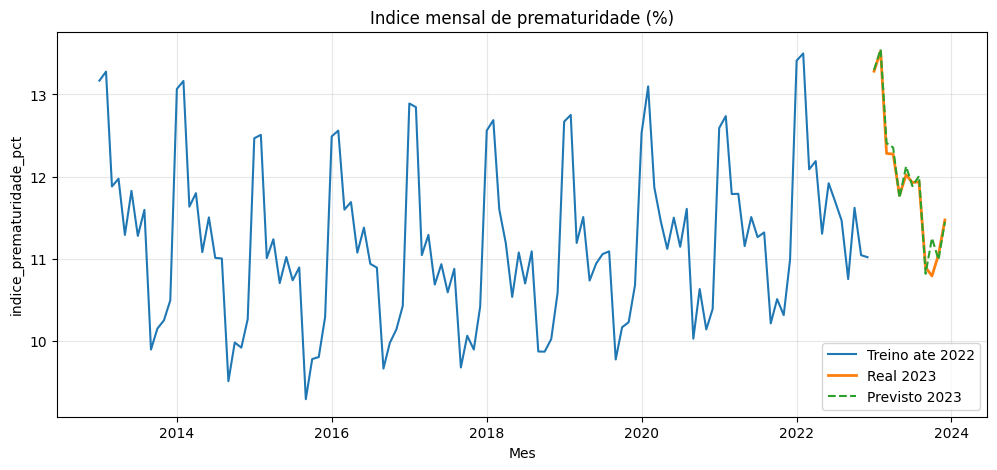

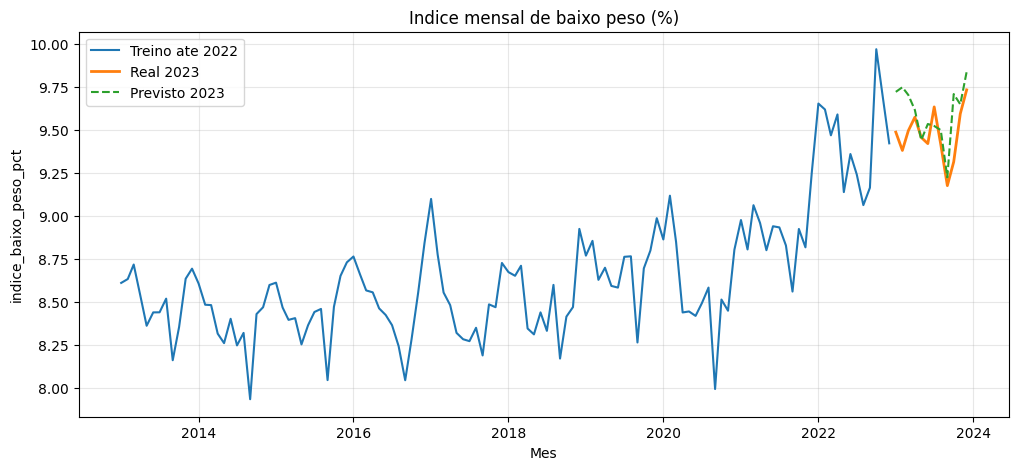

In [11]:
def plot_real_vs_pred(result: dict) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(result["train"].index, result["train"].values, label="Treino ate 2022")
    plt.plot(result["test_2023"].index, result["test_2023"].values, label="Real 2023", linewidth=2)
    plt.plot(result["pred_2023"].index, result["pred_2023"].values, label="Previsto 2023", linestyle="--")
    plt.title(result["title"])
    plt.xlabel("Mes")
    plt.ylabel(result["value_col"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_real_vs_pred(result_prem)
plot_real_vs_pred(result_baixo)

## 12. Resumo Metodologico

Estrutura adotada neste notebook:

- serie temporal mensal para dois indicadores epidemiologicos;
- treino do modelo com dados de janeiro de 2013 a dezembro de 2022;
- comparacao entre previsto e observado em 2023;
- reajuste do modelo com a serie completa para previsoes futuras;
- indicadores analisados: prematuridade e baixo peso ao nascer.

Definicoes:

- prematuridade mensal = nascimentos com `semagestac < 37` dividido pelo total de nascimentos do mes, multiplicado por 100;
- baixo peso mensal = nascimentos com `peso_int < 2500` dividido pelo total de nascimentos do mes, multiplicado por 100.

## 13. Modelo LSTM (Comparativo ao ARIMA)

Treino em 2013-2022, teste em 2023 e previsoes futuras de 1, 3 e 6 meses para os dois indicadores.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


def mape_safe(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan


def make_sequences(values_1d, lookback=12):
    X, y = [], []
    for i in range(lookback, len(values_1d)):
        X.append(values_1d[i - lookback:i])
        y.append(values_1d[i])
    return np.array(X), np.array(y)


def run_lstm_pipeline(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    lookback=12,
    epochs=250,
    batch_size=8,
    learning_rate=0.001,
    seed=42,
):
    tf.keras.utils.set_random_seed(seed)

    base, train, test_2023 = prepare_series(df, value_col)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()

    X_train, y_train = make_sequences(train_scaled, lookback=lookback)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    model = Sequential([
        LSTM(32, input_shape=(lookback, 1)),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    steps_test = len(test_2023)
    window = train_scaled[-lookback:].copy()
    preds_scaled = []

    for _ in range(steps_test):
        x_in = window.reshape(1, lookback, 1)
        p = model.predict(x_in, verbose=0).flatten()[0]
        preds_scaled.append(p)
        window = np.append(window[1:], p)

    pred_2023 = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    pred_2023 = pd.Series(pred_2023, index=test_2023.index, name="previsto_2023")

    mae = mean_absolute_error(test_2023.values, pred_2023.values)
    rmse = mean_squared_error(test_2023.values, pred_2023.values) ** 0.5
    mape = mape_safe(test_2023.values, pred_2023.values)

    compare_2023 = pd.DataFrame(
        {
            "real_2023": test_2023,
            "previsto_2023": pred_2023,
            "erro": test_2023 - pred_2023,
        }
    )

    full_scaled = scaler.fit_transform(base[value_col].values.reshape(-1, 1)).flatten()
    X_full, y_full = make_sequences(full_scaled, lookback=lookback)
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

    model_full = Sequential([
        LSTM(32, input_shape=(lookback, 1)),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model_full.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )
    model_full.fit(X_full, y_full, epochs=epochs, batch_size=batch_size, verbose=0)

    def forecast_future(n_steps):
        win = full_scaled[-lookback:].copy()
        out_scaled = []
        for _ in range(n_steps):
            p = model_full.predict(win.reshape(1, lookback, 1), verbose=0).flatten()[0]
            out_scaled.append(p)
            win = np.append(win[1:], p)

        out = scaler.inverse_transform(np.array(out_scaled).reshape(-1, 1)).flatten()
        future_idx = pd.date_range(base.index.max() + pd.offsets.MonthBegin(1), periods=n_steps, freq="MS")
        return pd.DataFrame({"forecast": out}, index=future_idx)

    fc_1 = forecast_future(1)
    fc_3 = forecast_future(3)
    fc_6 = forecast_future(6)

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train.values, label="Treino ate 2022")
    plt.plot(test_2023.index, test_2023.values, label="Real 2023", linewidth=2)
    plt.plot(pred_2023.index, pred_2023.values, label="Previsto 2023 (LSTM)", linestyle="--")
    plt.title(f"{title} - Real vs Previsto (2023)")
    plt.xlabel("Mes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "title": title,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "compare_2023": compare_2023,
        "forecast_1": fc_1,
        "forecast_3": fc_3,
        "forecast_6": fc_6,
    }

In [ ]:
lstm_prem = run_lstm_pipeline(
    df=df_prem,
    value_col="indice_prematuridade_pct",
    title="LSTM - Indice mensal de prematuridade (%)",
)

lstm_baixo = run_lstm_pipeline(
    df=df_baixo,
    value_col="indice_baixo_peso_pct",
    title="LSTM - Indice mensal de baixo peso (%)",
)

print("Metricas LSTM - Prematuridade")
print(lstm_prem["mae"], lstm_prem["rmse"], lstm_prem["mape"])

print("Metricas LSTM - Baixo peso")
print(lstm_baixo["mae"], lstm_baixo["rmse"], lstm_baixo["mape"])

In [ ]:
mae_arima_prem = float(result_prem["metrics"]["MAE"].iloc[0])
rmse_arima_prem = float(result_prem["metrics"]["RMSE"].iloc[0])
mape_arima_prem = float(result_prem["metrics"]["MAPE"].iloc[0])

mae_arima_baixo = float(result_baixo["metrics"]["MAE"].iloc[0])
rmse_arima_baixo = float(result_baixo["metrics"]["RMSE"].iloc[0])
mape_arima_baixo = float(result_baixo["metrics"]["MAPE"].iloc[0])

comparativo = pd.DataFrame([
    {"modelo": "ARIMA", "indicador": "prematuridade", "MAE": mae_arima_prem, "RMSE": rmse_arima_prem, "MAPE": mape_arima_prem},
    {"modelo": "LSTM", "indicador": "prematuridade", "MAE": lstm_prem["mae"], "RMSE": lstm_prem["rmse"], "MAPE": lstm_prem["mape"]},
    {"modelo": "ARIMA", "indicador": "baixo_peso", "MAE": mae_arima_baixo, "RMSE": rmse_arima_baixo, "MAPE": mape_arima_baixo},
    {"modelo": "LSTM", "indicador": "baixo_peso", "MAE": lstm_baixo["mae"], "RMSE": lstm_baixo["rmse"], "MAPE": lstm_baixo["mape"]},
])

display(comparativo)

print("Forecast LSTM 1/3/6 - Prematuridade")
display(lstm_prem["forecast_1"])
display(lstm_prem["forecast_3"])
display(lstm_prem["forecast_6"])

print("Forecast LSTM 1/3/6 - Baixo peso")
display(lstm_baixo["forecast_1"])
display(lstm_baixo["forecast_3"])
display(lstm_baixo["forecast_6"])